# EDA — Airbnb Listings

This notebook explores pricing, spatial patterns, and seasonality. The sample CSV is only a placeholder. Replace it with a real listings dataset for meaningful insights.

## EDA First: “Model-free” Insight

Before touching machine learning, a strong data scientist starts with Exploratory Data Analysis (EDA). Why?

Data quality check — Are prices realistic? Are lat/lon in range? Are dates valid? This avoids “garbage in → garbage out.”

Understanding distributions — Airbnb price data is notoriously skewed (a few luxury penthouses at $10,000/night). You need to see that before any model.

*Domain intuition:* EDA reveals what drives value: “Entire home/apt vs Private room” is a categorical driver, “neighborhood” matters spatially, and “number_of_reviews” or “availability” can proxy for demand.

📌 From a model-picking perspective: if you don’t explore distributions and relationships, you risk choosing an inappropriate model (e.g., a linear regression on raw price when log(price) is clearly a better target).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path().resolve().parent
sys.path.append(str(ROOT))

from src.data_loading import load_csv
from src.cleaning import clean_listings
from src.config import COLS
from src.utils import find_first_existing
from src.viz import save_hist, save_boxplot_by_cat, save_corr_heatmap, save_time_trend, save_map
sns.set(style='whitegrid')

DATA_PATH = ROOT/"data/raw/listings.csv"
df = load_csv(DATA_PATH)
df = clean_listings(df)
df.head()

,id,name,price,latitude,longitude,room_type,neighbourhood_cleansed,number_of_reviews,availability_365,last_review
0,1000,Listing 0,67.92,37.742321,-122.396353,Entire home/apt,Midtown,26,180,2023-08-12
1,1001,Listing 1,91.16,37.770536,-122.467346,Private room,Harbor,13,108,2023-08-14
2,1002,Listing 2,234.58,37.720650,-122.389418,Hotel room,Old Town,10,189,2023-12-11
3,1003,Listing 3,66.86,37.729275,-122.460328,Shared room,Midtown,24,226,2024-04-15
4,1004,Listing 4,316.00,37.727880,-122.440682,Shared room,Midtown,48,212,2023-08-22


## 1. Univariate Distributions

* Price distribution (hist + KDE), log-scale check if heavily skewed
* Review counts, availability
* Descriptive stats (quartiles, IQR, missingness)

### Why Univariate & Bivariate Plots?

We do histograms, boxplots, and correlation heatmaps because:

* They diagnose variance & skew → suggests if you need log-transformations or normalization.
* They reveal categorical splits (room type, neighborhood) → hints at strong features for modeling.
* They show potential leakage (e.g., “availability_365” may correlate with price but isn’t causal).

📌 Model link: These visuals guide feature engineering. For example:

* If reviews are heavily skewed → log-transform before feeding into regression.
* If neighborhoods dominate variance → consider target encoding or embeddings.

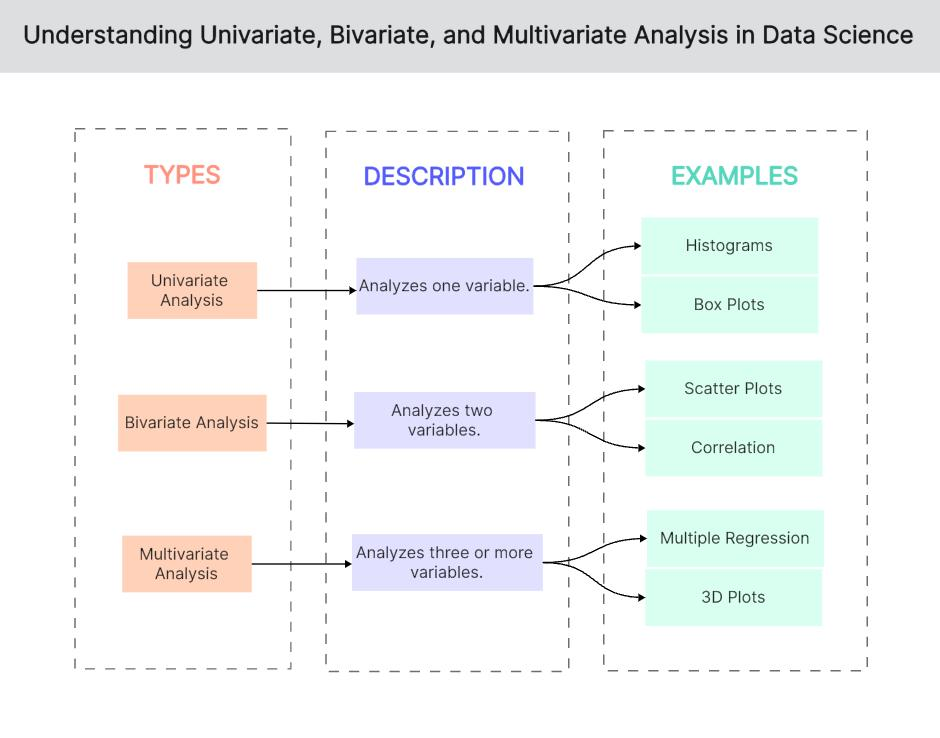

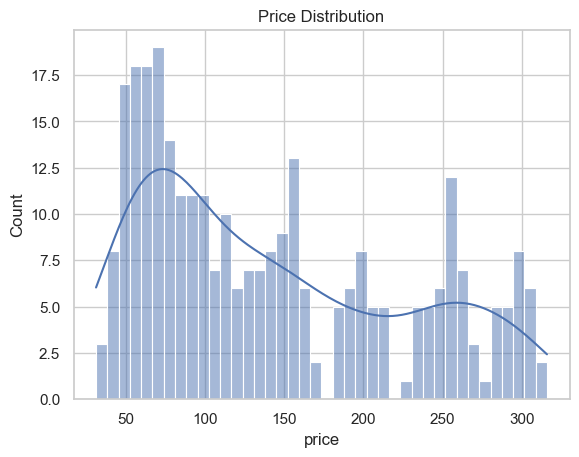

,count,mean,std,min,25%,50%,75%,max
id,300.0,1149.500000,86.746758,1000.000000,1074.750000,1149.500000,1224.250000,1299.000000
price,300.0,142.194667,81.554429,31.060000,71.137500,121.495000,202.602500,316.000000
latitude,300.0,37.769766,0.028966,37.720247,37.745445,37.766063,37.794838,37.819991
longitude,300.0,-122.420245,0.028544,-122.469885,-122.445182,-122.418719,-122.397478,-122.370137
number_of_reviews,300.0,25.543333,14.943420,0.000000,14.000000,24.000000,35.000000,76.000000
availability_365,300.0,203.713333,82.247797,0.000000,141.000000,205.000000,258.000000,365.000000


In [6]:
price_col = find_first_existing(df, COLS['price'])

if price_col:
    sns.histplot(df[price_col], bins=40, kde=True)
    plt.title('Price Distribution')
    plt.show()

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols].describe().T

## 2. Bivariate — Price vs Room Type / Neighborhood

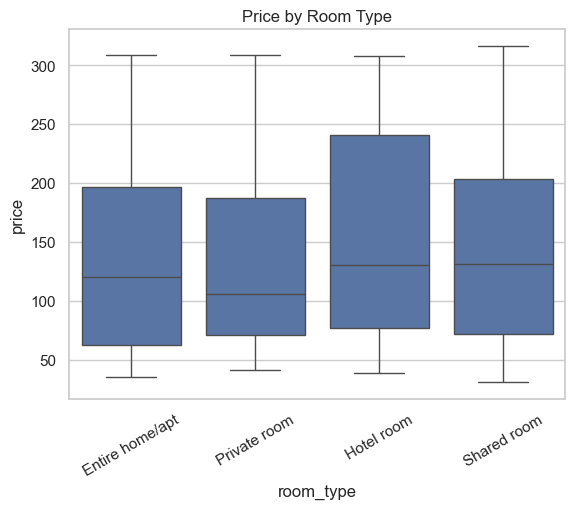

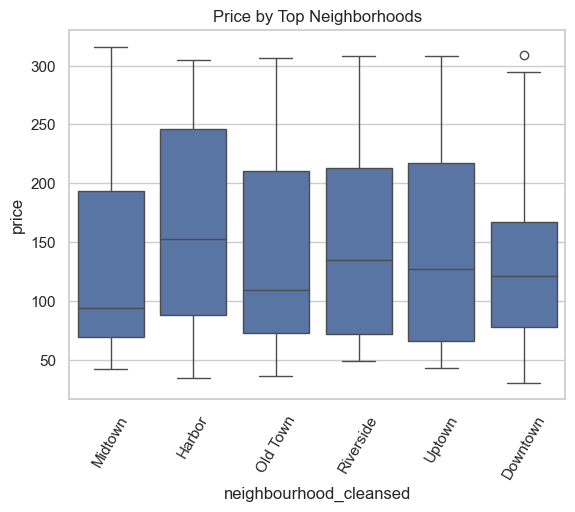

In [7]:
room_col = find_first_existing(df, COLS['room_type'])
neigh_col = find_first_existing(df, COLS['neighbourhood'])

if price_col and room_col:
    sns.boxplot(data=df, x=room_col, y=price_col)
    plt.title('Price by Room Type')
    plt.xticks(rotation=30)
    plt.show()

if price_col and neigh_col:
    top_neigh = df[neigh_col].value_counts().head(12).index
    sns.boxplot(data=df[df[neigh_col].isin(top_neigh)], x=neigh_col, y=price_col)
    plt.title('Price by Top Neighborhoods')
    plt.xticks(rotation=60)
    plt.show()

## 3. Correlations

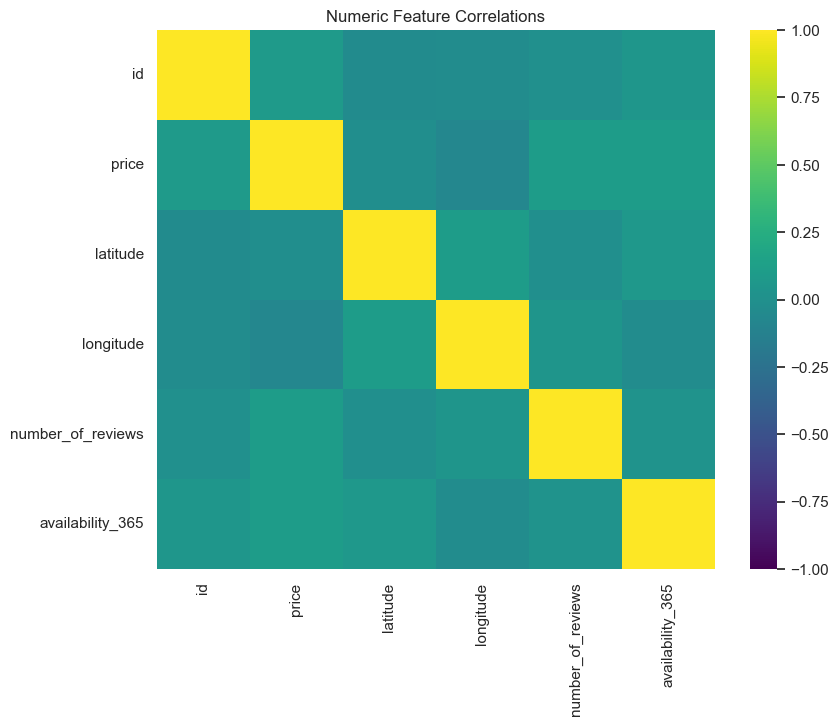

In [8]:
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap='viridis', vmin=-1, vmax=1)
plt.title('Numeric Feature Correlations')
plt.show()

## 4. Time Trends (if a date column exists)

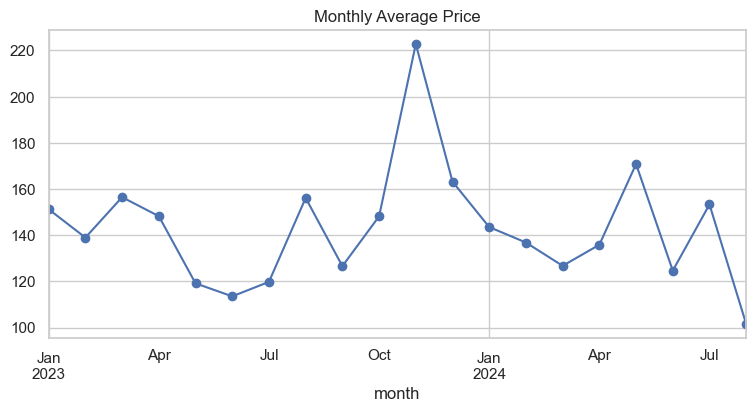

In [27]:
date_col = find_first_existing(df, COLS['last_review'])
if date_col and price_col:
    d = df[[date_col, price_col]].dropna().copy()
    d['month'] = d[date_col].dt.to_period('M').dt.to_timestamp()
    ts = d.groupby('month')[price_col].mean()
    ts.plot(marker='o', figsize=(9,4), title='Monthly Average Price')
    plt.show()
else:
    print('No suitable date column found; skipping time trend.')

## 5. Map (Folium)

In [28]:
out_map = save_map(df, Path('reports/figures'), price_col)
out_map

PosixPath('reports/figures/map_listings.html')

## 6. Notes & Findings

- Summarize key drivers of price.
- Note any data quality caveats.
- Capture seasonality observations, if applicable.